This is a minimal implementation a Vqriational Quantum Eigensolver using Qulacs.

In [1]:
# Standard library
from functools import reduce

# Scientific computing
import numpy as np
import sympy as sp
from scipy.optimize import minimize

# Visualisation
import matplotlib.pyplot as plt

# Qulacs
from qulacs import QuantumState, QuantumCircuit, Observable
from qulacs.gate import CNOT, RY
from qulacs.observable import create_observable_from_openfermion_text
from qulacsvis import circuit_drawer

# OpenFermion
from openfermion.ops import QubitOperator

# Jupyter display
from IPython.display import Math, display

### No of qubit and other params

In [2]:
n_qubit: int = 2

### The Target Hamiltonian

Let us consider finding the minimum eigenvalue of the following matrix, which represents a physical Hamiltonian:

$$
\begin{pmatrix}
2 & 0 & 0 & 1 \\
0 & 0 & 1 & 0 \\
0 & 1 & 0 & 0 \\
1 & 0 & 0 & -2
\end{pmatrix}
$$

To encode $H$ on a quantum computer, it must be expressed as a linear combination of Pauli operators. One can verify that $H$ admits the decomposition

$$H = X_1 X_2 + Z_1 + Z_2$$

This is a two-qubit instance of the transverse-field Ising Hamiltonian. More generally, for an $N$-qubit chain this generalises to

$$ H_\text{Ising} = \sum_{k=1}^{N-1}X_k X_{k+1} + \sum_{k=0}^{N} Z_k$$

In [ ]:
def create_ising_hamiltonian(nqubits: int) -> Observable:
    r"""
    Creates an Ising Hamiltonian:

        .. math::

            H_\text{Ising} = \sum_{k=0}^{N-2} X_k X_{k+1} + \sum_{k=0}^{N-1} Z_k

    Args:
        nqubits (int): The number of qubits.

    Returns:def ansatz(n_qubit, theta_list):
    """
    Args:
    n_qubit (int): Number of qubits.
    theta_list (array-like): Four variational parameters [t0, t1, t2, t3].
        t0, t1 -- pre-entanglement RY angles on qubits 0 and 1.
        t2, t3 -- post-entanglement RY angles on qubits 0 and 1.

    Returns:
        QuantumCircuit: Parameterized Qulacs circuit.
    """
    circuit = QuantumCircuit(n_qubit)

    # Pre-entanglement layer: independent single-qubit rotations
    for i in range(n_qubit):
        circuit.add_gate(RY(i, theta_list[i]))

    # Entangling layer: CNOT mirrors the X0 X1 coupling in H
    circuit.add_gate(CNOT(0, 1))

    # Post-entanglement layer: variational adjustment within entangled subspace
    for i in range(n_qubit):
        circuit.add_gate(RY(i, theta_list[n_qubit + i]))

    return circuit
        Observable: Qulacs observable representing the Hamiltonian.
    """
    hami = QubitOperator()
    for i in range(nqubits - 1):
        hami += QubitOperator(f"X{i} X{i+1}")
    for j in range(nqubits):
        hami += QubitOperator(f"Z{j}")
    return create_observable_from_openfermion_text(str(hami))

In [4]:
TARGET_HAMI = create_ising_hamiltonian(n_qubit)

In [5]:
eigenvalues, _ = np.linalg.eigh(TARGET_HAMI.get_matrix().toarray())
min_eigenvalue = np.min(eigenvalues)
print(f"Minimum eigenvalue of the target Hamiltonian: {min_eigenvalue:.6f}")

Minimum eigenvalue of the target Hamiltonian: -2.236068


### Create Ansatz

The structure of the Hamiltonian provides two key insights that guide the design of the variational ansatz.

First, the ground state is inherently entangled. The presence of the $X_0 X_1$ interaction term directly couples the two qubits, implying that the ground state cannot, in general, be expressed as a separable product state. Consequently, the ansatz must be capable of generating entanglement. This requirement is naturally fulfilled by the inclusion of a two-qubit entangling gate, such as a CNOT, applied between qubits $0$ and $1$, which are precisely the qubits coupled by the Hamiltonian.

Second, the ground state can be represented with real amplitudes. Since the Hamiltonian matrix is purely real and symmetric, its eigenvectors can always be chosen to have real coefficients. This observation motivates restricting the ansatz to operations that preserve real-valued state amplitudes. In this context, the single-qubit rotation $R_Y(\theta)$ is a natural choice. In contrast, $R_X(\theta)$ and $R_Z(\theta)$ generally introduce complex phases that are not required for representing the ground state.


In [6]:
def ansatz(n_qubit, theta_list):
    """
    Args:
    n_qubit (int): Number of qubits.
    theta_list (array-like): Four variational parameters [t0, t1, t2, t3].
        t0, t1 -- pre-entanglement RY angles on qubits 0 and 1.
        t2, t3 -- post-entanglement RY angles on qubits 0 and 1.

    Returns:
        QuantumCircuit: Parameterized Qulacs circuit.
    """
    circuit = QuantumCircuit(n_qubit)

    # Pre-entanglement layer: independent single-qubit rotations
    for i in range(n_qubit):
        circuit.add_gate(RY(i, theta_list[i]))

    # Entangling layer: CNOT mirrors the X0 X1 coupling in H
    circuit.add_gate(CNOT(0, 1))

    # Post-entanglement layer: variational adjustment within entangled subspace
    for i in range(n_qubit):
        circuit.add_gate(RY(i, theta_list[n_qubit + i]))

    return circuit

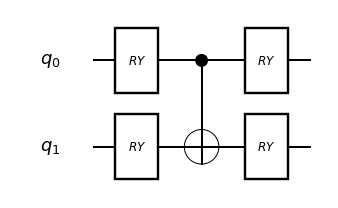

In [7]:
depth = n_qubit
test_circuit = ansatz(n_qubit, np.random.rand(2*n_qubit*(depth+1)))
circuit_drawer(test_circuit, "mpl")

### Cost function

In [8]:
def cost(theta_list):
    state = QuantumState(n_qubit)
    circuit = ansatz(n_qubit, theta_list)
    circuit.update_quantum_state(state)
    return TARGET_HAMI.get_expectation_value(state)

# Initialise parameters uniformly in [-pi, pi]
np.random.seed(0)
init_theta_list = np.random.uniform(-np.pi, np.pi, 2 * n_qubit)

cost_history = [cost(init_theta_list)]

opt = minimize(
    cost,
    init_theta_list,
    method='BFGS',
    callback=lambda x: cost_history.append(cost(x))
)

print(f'VQE result:         {opt.fun:.6f}')
print(f'Exact ground state: {min_eigenvalue:.6f}')
print(f'Absolute error:     {abs(opt.fun - min_eigenvalue):.2e}')

VQE result:         -2.236068
Exact ground state: -2.236068
Absolute error:     1.22e-11


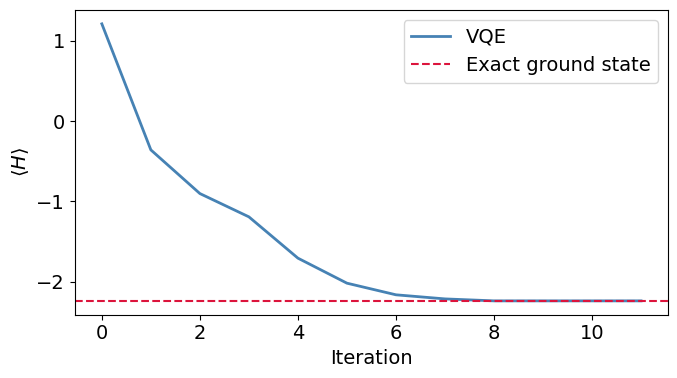

In [9]:
plt.rcParams['font.size'] = 14
plt.figure(figsize=(7, 4))
plt.plot(cost_history, color='steelblue', linewidth=2, label='VQE')
plt.axhline(min_eigenvalue, color='crimson', linestyle='--', linewidth=1.5, label='Exact ground state')
plt.xlabel('Iteration')
plt.ylabel(r'$\langle H \rangle$')
#plt.title()
plt.legend()
plt.tight_layout()
plt.show()

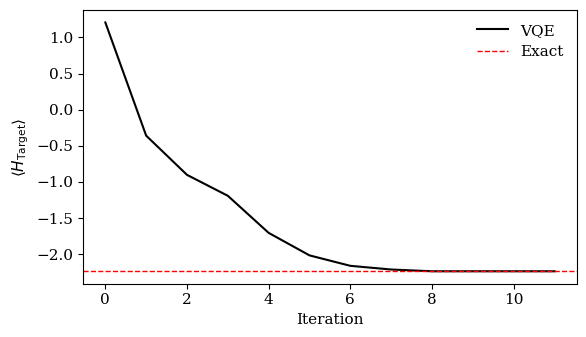

In [17]:
import matplotlib.pyplot as plt

# Minimal professional defaults
plt.rcParams.update({
    "font.family": "serif",
    "font.size": 11,
    "axes.linewidth": 0.8,
    "grid.alpha": 0.3
})

plt.figure(figsize=(6, 3.5)) # Slightly more compact

# Plotting
plt.plot(cost_history, color='black', linewidth=1.5, label='VQE')
plt.axhline(min_eigenvalue, color='red', linestyle='--', linewidth=1, label='Exact')

# Labels
plt.xlabel('Iteration')
plt.ylabel(r'$\langle H_{\text{Target}} \rangle$')

# Remove unnecessary frame lines (top and right) for a modern look
ax = plt.gca()
# ax.spines['top'].set_visible(False)
# ax.spines['right'].set_visible(False)

plt.legend(frameon=False)
plt.tight_layout()

# Save as PDF for your LaTeX document
plt.savefig('vqe-min.eps', format='eps')
plt.show()